## Predicting WDAY Quarterly Return Direction Using AI Disclosure Intensity

**Research question**: Does AI disclosure intensity (AII) contain incremental predictive
information about Workday's next-quarter stock return direction, beyond historical price
dynamics alone?

### Prediction Problems

| Task | Target | Metric |
|------|--------|--------|
| **Binary classification** | `Target` (1=up, 0=flat/down) | Accuracy, ROC-AUC |
| **Regression** | `log_return` (quarterly log return) | MAE, RMSE |

### Feature Sets

| Feature Set | Variables |
|-------------|----------|
| **Price-only baseline** | `log_return_lag1`, `log_return_lag2` |
| **AII-augmented** | Above + `aii_lag1`, `aii_delta_lag1`, `bucket_classic_ai_lag1`, `bucket_generative_ai_lag1`, `bucket_adj_auto_lag1` |

### Leakage Policy

AII(Q) is finalized at the end of quarter Q. It is lagged by one quarter before joining
to the WDAY return frame, so AII(Q) predicts Return(Q+1). This is conservative enough
for quarterly prediction even accounting for the ~40-day 10-Q filing delay.

**Chronological splits** (per `CLAUDE.md`):
- Train: 2015-Q1 – 2019-Q4 (20 quarters)
- Validation: 2020-Q1 – 2021-Q4 (8 quarters)
- Test: 2022-Q1 – 2025-Q4 (16 quarters)

In [1]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

import os
import numpy as np
import polars as pl
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

import xgboost as xgb
from xgboost import XGBRegressor, XGBClassifier, plot_importance

print(f"polars  {pl.__version__}")
print(f"xgboost {xgb.__version__}")
print(f"yfinance {yf.__version__}")

polars  1.38.1
xgboost 3.2.0
yfinance 1.2.0


### Retrieve WDAY Quarterly Price Data

WDAY IPO'd in October 2012. We fetch quarterly bars from 2012-Q3 through 2025-Q4.
The raw file is saved for reproducibility.

In [2]:
SYMBOL = 'WDAY'
RAW_CSV = 'wday_historical_data.csv'

ticker = yf.Ticker(SYMBOL)
wday_raw = ticker.history(start='2012-07-01', end='2026-01-01', interval='3mo')
wday_raw.to_csv(RAW_CSV)
print(f"Downloaded {len(wday_raw)} quarterly bars → saved to {RAW_CSV}")
print(wday_raw.tail())

Downloaded 53 quarterly bars → saved to wday_historical_data.csv
                                 Open        High         Low       Close  \
Date                                                                        
2024-10-01 00:00:00-04:00  243.940002  294.000000  231.740005  258.029999   
2025-01-01 00:00:00-05:00  260.679993  283.679993  229.289993  233.529999   
2025-04-01 00:00:00-04:00  232.949997  276.000000  205.330002  240.000000   
2025-07-01 00:00:00-04:00  238.589996  249.850006  206.770004  240.729996   
2025-10-01 00:00:00-04:00  239.350006  247.399994  207.669998  214.779999   

                              Volume  Dividends  Stock Splits  
Date                                                           
2024-10-01 00:00:00-04:00  204090500        0.0           0.0  
2025-01-01 00:00:00-05:00  133410700        0.0           0.0  
2025-04-01 00:00:00-04:00  142804800        0.0           0.0  
2025-07-01 00:00:00-04:00  212637800        0.0           0.0  
2025-10-01 

In [3]:
# Load with Polars
wday = pl.read_csv(RAW_CSV, try_parse_dates=True)
print(wday.schema)

# Drop non-price columns if present
drop_cols = [c for c in ['Dividends', 'Stock Splits', 'Capital Gains'] if c in wday.columns]
if drop_cols:
    wday = wday.drop(drop_cols)

# Parse date → year and quarter integers
date_col = wday.columns[0]  # 'Date' or 'Datetime'
wday = wday.rename({date_col: 'Date'})

# Cast Date column to Date type if it came in as string
if wday['Date'].dtype == pl.Utf8:
    wday = wday.with_columns(pl.col('Date').str.slice(0, 10).str.to_date('%Y-%m-%d'))
elif wday['Date'].dtype == pl.Datetime:
    wday = wday.with_columns(pl.col('Date').cast(pl.Date))

wday = wday.with_columns([
    pl.col('Date').dt.year().alias('year'),
    ((pl.col('Date').dt.month() - 1) // 3 + 1).alias('quarter'),
])

# Lag close prices for return computation
wday = wday.with_columns(pl.col('Close').shift(1).alias('CloseLag1'))

# Log return and lagged log returns (price baseline features)
wday = wday.with_columns(
    (np.log(pl.col('Close') / pl.col('CloseLag1'))).alias('log_return')
)
wday = wday.with_columns([
    pl.col('log_return').shift(1).alias('log_return_lag1'),
    pl.col('log_return').shift(2).alias('log_return_lag2'),
])

# Binary direction target: 1=up, 0=flat/down
wday = wday.with_columns(
    pl.when(pl.col('log_return') > 0.0).then(pl.lit(1)).otherwise(pl.lit(0)).alias('Target')
)

# Round numeric columns
for col in ['Close', 'CloseLag1', 'log_return', 'log_return_lag1', 'log_return_lag2']:
    wday = wday.with_columns(pl.col(col).round(6))

print(wday.schema)
wday.write_csv('wday-with-computed-features.csv')
print(f"Saved wday-with-computed-features.csv  ({wday.shape[0]} rows)")

Schema({'Date': Datetime(time_unit='us', time_zone='UTC'), 'Open': Float64, 'High': Float64, 'Low': Float64, 'Close': Float64, 'Volume': Int64, 'Dividends': Float64, 'Stock Splits': Float64})
Schema({'Date': Date, 'Open': Float64, 'High': Float64, 'Low': Float64, 'Close': Float64, 'Volume': Int64, 'year': Int32, 'quarter': Int8, 'CloseLag1': Float64, 'log_return': Float64, 'log_return_lag1': Float64, 'log_return_lag2': Float64, 'Target': Int32})
Saved wday-with-computed-features.csv  (53 rows)


### Descriptive Statistics for Price Features

In [4]:
# Drop rows with nulls (initial lag rows)
wday = wday.drop_nulls()

wday_stats = wday.select(['Close', 'log_return', 'log_return_lag1', 'log_return_lag2', 'Target']).describe()

with pl.Config(
    tbl_rows=20,
    tbl_width_chars=200,
    tbl_cols=-1,
    float_precision=4,
    tbl_hide_dataframe_shape=True,
    tbl_hide_column_data_types=True,
):
    print(wday_stats)

┌────────────┬──────────┬────────────┬─────────────────┬─────────────────┬─────────┐
│ statistic  ┆ Close    ┆ log_return ┆ log_return_lag1 ┆ log_return_lag2 ┆ Target  │
╞════════════╪══════════╪════════════╪═════════════════╪═════════════════╪═════════╡
│ count      ┆ 50.0000  ┆ 50.0000    ┆ 50.0000         ┆ 50.0000         ┆ 50.0000 │
│ null_count ┆ 0.0000   ┆ 0.0000     ┆ 0.0000          ┆ 0.0000          ┆ 0.0000  │
│ mean       ┆ 162.6908 ┆ 0.0242     ┆ 0.0273          ┆ 0.0296          ┆ 0.5800  │
│ std        ┆ 70.2146  ┆ 0.1592     ┆ 0.1579          ┆ 0.1585          ┆ 0.4986  │
│ min        ┆ 66.0900  ┆ -0.5397    ┆ -0.5397         ┆ -0.5397         ┆ 0.0000  │
│ 25%        ┆ 89.8600  ┆ -0.0483    ┆ -0.0398         ┆ -0.0398         ┆ 0.0000  │
│ 50%        ┆ 164.4500 ┆ 0.0361     ┆ 0.0391          ┆ 0.0456          ┆ 1.0000  │
│ 75%        ┆ 233.5300 ┆ 0.1078     ┆ 0.1078          ┆ 0.1229          ┆ 1.0000  │
│ max        ┆ 276.0600 ┆ 0.3638     ┆ 0.3638          ┆ 0.3638  

### Load AII Quarterly Features

54 quarters from 2012-Q4 to 2025-Q4. Columns: `period`, `year`, `quarter`, `doc_count`,
`aii`, `aii_delta`, `bucket_classic_ai`, `bucket_generative_ai`, `bucket_adjacent_automation`.

In [5]:
aii = pl.read_csv('../data/processed/aii_quarterly.csv')

print(f"AII quarters: {aii.shape[0]}")
print(f"Period range: {aii['period'].min()} → {aii['period'].max()}")

with pl.Config(
    tbl_rows=10,
    tbl_width_chars=200,
    tbl_cols=-1,
    float_precision=4,
    tbl_hide_dataframe_shape=True,
    tbl_hide_column_data_types=True,
):
    print(aii.head(10))

AII quarters: 53
Period range: 2012-Q4 → 2025-Q4
┌─────────┬──────┬─────────┬───────────┬────────┬───────────┬───────────────────┬────────────────┬─────────────────────┬───────────────────┬──────────────────────┬────────────────────────────┐
│ period  ┆ year ┆ quarter ┆ doc_count ┆ aii    ┆ aii_delta ┆ quarter_raw_score ┆ quarter_tokens ┆ avg_doc_type_weight ┆ bucket_classic_ai ┆ bucket_generative_ai ┆ bucket_adjacent_automation │
╞═════════╪══════╪═════════╪═══════════╪════════╪═══════════╪═══════════════════╪════════════════╪═════════════════════╪═══════════════════╪══════════════════════╪════════════════════════════╡
│ 2012-Q4 ┆ 2012 ┆ 4       ┆ 1         ┆ 0.0000 ┆ null      ┆ 0.0000            ┆ 42485.8000     ┆ 1.2000              ┆ 0                 ┆ 0                    ┆ 0                          │
│ 2013-Q1 ┆ 2013 ┆ 1       ┆ 1         ┆ 0.0000 ┆ 0.0000    ┆ 0.0000            ┆ 69285.5000     ┆ 1.5000              ┆ 0                 ┆ 0                    ┆ 0              

### Merge and Lag AII (Leakage-Safe)

AII(Q) is finalized at end of quarter Q. We shift AII by 1 row so that AII(Q) is used
to predict Return(Q+1) — i.e., AII from the *previous* quarter predicts the *current*
quarter's return.

In [6]:
# Create lagged AII columns (shift within AII frame before joining)
aii_lagged = aii.with_columns([
    pl.col('period').shift(1).alias('aii_source_period'),  # shifted: shows actual source quarter
    pl.col('aii').shift(1).alias('aii_lag1'),
    pl.col('aii_delta').shift(1).alias('aii_delta_lag1'),
    pl.col('bucket_classic_ai').shift(1).alias('bucket_classic_ai_lag1'),
    pl.col('bucket_generative_ai').shift(1).alias('bucket_generative_ai_lag1'),
    pl.col('bucket_adjacent_automation').shift(1).alias('bucket_adj_auto_lag1'),
])

# Keep only columns needed for join + lagged features
aii_join = aii_lagged.select([
    'year', 'quarter', 'period', 'aii_source_period', 'doc_count',
    'aii_lag1', 'aii_delta_lag1',
    'bucket_classic_ai_lag1', 'bucket_generative_ai_lag1', 'bucket_adj_auto_lag1',
])

# Join WDAY returns with lagged AII on year/quarter
modeling = wday.join(aii_join, on=['year', 'quarter'], how='left')

# Restrict to 2015-Q1 onward (sparse AII pre-2015, <2yr price history)
modeling = modeling.filter(
    (pl.col('year') > 2015) | ((pl.col('year') == 2015) & (pl.col('quarter') >= 1))
)

# Drop rows with nulls after lag and join
modeling = modeling.drop_nulls(subset=['log_return_lag1', 'log_return_lag2', 'aii_lag1'])

print(f"Modeling dataset: {modeling.shape[0]} rows, {modeling.shape[1]} columns")
print(f"Period range: {modeling['period'].min()} → {modeling['period'].max()}")

Modeling dataset: 44 rows, 21 columns
Period range: 2015-Q1 → 2025-Q4


### Leakage Audit Table

Verification that AII source is always Q-1 relative to the return being predicted.

In [7]:
audit = modeling.select([
    'period',
    'log_return',
    'aii_lag1',
    'aii_source_period',
]).head(20)

print("Leakage Audit: AII source period should always be Q-1 relative to prediction period")
print()
with pl.Config(
    tbl_rows=25,
    tbl_width_chars=200,
    tbl_cols=-1,
    float_precision=4,
    tbl_hide_dataframe_shape=True,
    tbl_hide_column_data_types=True,
):
    print(audit)

# Spot check: first row 2015-Q1 should show AII from 2014-Q4
first_row = modeling.row(0, named=True)
print(f"\nSpot check — prediction period: {first_row['period']}, AII source: {first_row['aii_source_period']}")
assert first_row['aii_source_period'] < first_row['period'], \
    "LEAKAGE DETECTED: AII source is not strictly before prediction period!"
print("PASS: AII source period is strictly before prediction period.")

Leakage Audit: AII source period should always be Q-1 relative to prediction period

┌─────────┬────────────┬──────────┬───────────────────┐
│ period  ┆ log_return ┆ aii_lag1 ┆ aii_source_period │
╞═════════╪════════════╪══════════╪═══════════════════╡
│ 2015-Q1 ┆ 0.0337     ┆ 0.0430   ┆ 2014-Q4           │
│ 2015-Q2 ┆ -0.0998    ┆ 0.0575   ┆ 2015-Q1           │
│ 2015-Q3 ┆ -0.1038    ┆ 0.0000   ┆ 2015-Q2           │
│ 2015-Q4 ┆ 0.1459     ┆ 0.0000   ┆ 2015-Q3           │
│ 2016-Q1 ┆ -0.0363    ┆ 0.0000   ┆ 2015-Q4           │
│ 2016-Q2 ┆ -0.0286    ┆ 0.0203   ┆ 2016-Q1           │
│ 2016-Q3 ┆ 0.2053     ┆ 0.0000   ┆ 2016-Q2           │
│ 2016-Q4 ┆ -0.3274    ┆ 0.0000   ┆ 2016-Q3           │
│ 2017-Q1 ┆ 0.2312     ┆ 0.0000   ┆ 2016-Q4           │
│ 2017-Q2 ┆ 0.1525     ┆ 0.0165   ┆ 2017-Q1           │
│ 2017-Q3 ┆ 0.0830     ┆ 0.0000   ┆ 2017-Q2           │
│ 2017-Q4 ┆ -0.0352    ┆ 0.0000   ┆ 2017-Q3           │
│ 2018-Q1 ┆ 0.2226     ┆ 0.0000   ┆ 2017-Q4           │
│ 2018-Q2 ┆ -0.0483

### Feature and Target Definition

In [8]:
# Price-only baseline features
PRICE_FEATURES = ['log_return_lag1', 'log_return_lag2']

# AII-augmented features
AII_FEATURES = [
    'log_return_lag1', 'log_return_lag2',
    'aii_lag1', 'aii_delta_lag1',
    'bucket_classic_ai_lag1', 'bucket_generative_ai_lag1', 'bucket_adj_auto_lag1',
]

# Regression target
y_reg = np.array(modeling['log_return'])

# Classification target
y_cls = np.array(modeling['Target'])

# Feature matrices
X_price = np.array(modeling.select(PRICE_FEATURES))
X_aii   = np.array(modeling.select(AII_FEATURES))

print("Feature sets:")
print(f"  Price-only:    {X_price.shape}  {PRICE_FEATURES}")
print(f"  AII-augmented: {X_aii.shape}  {AII_FEATURES}")
print()
print("Regression target (log_return):")
print(f"  mean={y_reg.mean():.4f}, std={y_reg.std():.4f}, min={y_reg.min():.4f}, max={y_reg.max():.4f}")
print()
print("Classification target (Target) class balance:")
print(modeling['Target'].value_counts().sort('Target'))

Feature sets:
  Price-only:    (44, 2)  ['log_return_lag1', 'log_return_lag2']
  AII-augmented: (44, 7)  ['log_return_lag1', 'log_return_lag2', 'aii_lag1', 'aii_delta_lag1', 'bucket_classic_ai_lag1', 'bucket_generative_ai_lag1', 'bucket_adj_auto_lag1']

Regression target (log_return):
  mean=0.0220, std=0.1636, min=-0.5397, max=0.3638

Classification target (Target) class balance:
shape: (2, 2)
┌────────┬───────┐
│ Target ┆ count │
│ ---    ┆ ---   │
│ i32    ┆ u32   │
╞════════╪═══════╡
│ 0      ┆ 18    │
│ 1      ┆ 26    │
└────────┴───────┘


### Chronological Train / Validation / Test Split

Per `CLAUDE.md` specification:

| Split | Period | Quarters |
|-------|--------|----------|
| Train | 2015-Q1 – 2019-Q4 | 20 |
| Validation | 2020-Q1 – 2021-Q4 | 8 |
| Test | 2022-Q1 – 2025-Q4 | 16 |

In [9]:
def in_range(df, year_start, q_start, year_end, q_end):
    """Boolean mask for rows in [year_start-q_start, year_end-q_end]."""
    start_val = year_start * 10 + q_start
    end_val   = year_end   * 10 + q_end
    vals = df['year'] * 10 + df['quarter']
    return ((vals >= start_val) & (vals <= end_val)).to_numpy().astype(bool)

mask_train = in_range(modeling, 2015, 1, 2019, 4)
mask_val   = in_range(modeling, 2020, 1, 2021, 4)
mask_test  = in_range(modeling, 2022, 1, 2025, 4)

print(f"Train rows:      {mask_train.sum()}  (expected ~20)")
print(f"Validation rows: {mask_val.sum()}    (expected ~8)")
print(f"Test rows:       {mask_test.sum()}   (expected ~16)")
print(f"Total:           {mask_train.sum() + mask_val.sum() + mask_test.sum()} / {len(modeling)} (unassigned rows have sparse AII)")

# Training arrays
X_price_train = X_price[mask_train]
X_aii_train   = X_aii[mask_train]
y_reg_train   = y_reg[mask_train]
y_cls_train   = y_cls[mask_train]

# Validation arrays
X_price_val = X_price[mask_val]
X_aii_val   = X_aii[mask_val]
y_reg_val   = y_reg[mask_val]
y_cls_val   = y_cls[mask_val]

# Test arrays
X_price_test = X_price[mask_test]
X_aii_test   = X_aii[mask_test]
y_reg_test   = y_reg[mask_test]
y_cls_test   = y_cls[mask_test]

Train rows:      20  (expected ~20)
Validation rows: 8    (expected ~8)
Test rows:       16   (expected ~16)
Total:           44 / 44 (unassigned rows have sparse AII)


### TimeSeriesSplit CV (within training set only)

`gap=1` quarter prevents any lookahead from leaking across the fold boundary.

In [10]:
tscv = TimeSeriesSplit(n_splits=5, gap=1)

all_splits = list(tscv.split(X_price_train, y_cls_train))

print(f"TimeSeriesSplit: {tscv.n_splits} splits, gap={tscv.gap}")
print()
for i, (train_idx, test_idx) in enumerate(all_splits):
    print(f"Split {i}: train [{min(train_idx)}–{max(train_idx)}]  "
          f"({len(train_idx)} rows)   "
          f"test [{min(test_idx)}–{max(test_idx)}]  "
          f"({len(test_idx)} rows)")

TimeSeriesSplit: 5 splits, gap=1

Split 0: train [0–3]  (4 rows)   test [5–7]  (3 rows)
Split 1: train [0–6]  (7 rows)   test [8–10]  (3 rows)
Split 2: train [0–9]  (10 rows)   test [11–13]  (3 rows)
Split 3: train [0–12]  (13 rows)   test [14–16]  (3 rows)
Split 4: train [0–15]  (16 rows)   test [17–19]  (3 rows)


### Baseline Regression Model (Price Features Only)

In [11]:
def evaluate_regression(model, X, y, cv):
    cv_results = cross_validate(
        model, X, y, cv=cv,
        scoring=['neg_mean_absolute_error', 'neg_root_mean_squared_error'],
        return_estimator=True,
    )
    mae  = -cv_results['test_neg_mean_absolute_error']
    rmse = -cv_results['test_neg_root_mean_squared_error']
    print(
        f"Mean Absolute Error:     {mae.mean():.4f} +/- {mae.std():.4f}\n"
        f"Root Mean Squared Error: {rmse.mean():.4f} +/- {rmse.std():.4f}"
    )
    return cv_results


reg_price = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100, max_depth=3, learning_rate=0.1,
    random_state=42,
)

print("=== Baseline Regression (price features only) ===")
evaluate_regression(reg_price, X_price_train, y_reg_train, cv=tscv)

=== Baseline Regression (price features only) ===


Mean Absolute Error:     0.1736 +/- 0.0209
Root Mean Squared Error: 0.1932 +/- 0.0298


{'fit_time': array([0.04848719, 0.05556107, 0.06330323, 0.06259799, 0.06222105]),
 'score_time': array([0.00132895, 0.00060105, 0.00066495, 0.00064301, 0.00062895]),
 'estimator': [XGBRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.1, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=100,
               n_jobs=None, num_parallel_tree=None, ...),
  XGBRegressor(base_score=None, booster=None, callbac

### Baseline Classification Model (Price Features Only)

In [12]:
def evaluate_classification(model, X, y, cv, label=''):
    cv_results = cross_validate(
        model, X, y, cv=cv,
        scoring=['accuracy'],
        return_estimator=True,
    )
    accuracy = cv_results['test_accuracy']
    print(
        f"Mean Accuracy: {accuracy.mean():.4f} +/- {accuracy.std():.4f}"
    )
    return cv_results


clf_price = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100, max_depth=3, learning_rate=0.1,
    random_state=42, eval_metric='logloss',
)

print("=== Baseline Classification (price features only) ===")
evaluate_classification(clf_price, X_price_train, y_cls_train, cv=tscv)

=== Baseline Classification (price features only) ===
Mean Accuracy: 0.4667 +/- 0.2667


{'fit_time': array([0.02312708, 0.02488804, 0.03131008, 0.04037118, 0.04550004]),
 'score_time': array([0.00078583, 0.00054193, 0.00055909, 0.00043678, 0.00048518]),
 'estimator': [XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric='logloss',
                feature_types=None, feature_weights=None, gamma=None,
                grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=0.1, max_bin=None,
                max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=3, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=100, n_jobs=None,
                num_parallel_tree=None, ...),
  XGBClassifier(base_

### AII-Augmented Classification Model

In [13]:
clf_aii = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100, max_depth=3, learning_rate=0.1,
    random_state=42, eval_metric='logloss',
)

print("=== AII-Augmented Classification ===")
evaluate_classification(clf_aii, X_aii_train, y_cls_train, cv=tscv)

=== AII-Augmented Classification ===


Mean Accuracy: 0.4000 +/- 0.2494


{'fit_time': array([0.02318215, 0.02376294, 0.02900386, 0.04070783, 0.04261494]),
 'score_time': array([0.0006249 , 0.00062895, 0.00052595, 0.00054598, 0.00057602]),
 'estimator': [XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric='logloss',
                feature_types=None, feature_weights=None, gamma=None,
                grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=0.1, max_bin=None,
                max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=3, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=100, n_jobs=None,
                num_parallel_tree=None, ...),
  XGBClassifier(base_

### Hold-Out Evaluation (Validation + Test)

Models fit on training set only. Evaluated separately on validation and test splits.


--- Price-only | Validation ---
Accuracy: 0.3750   ROC-AUC: 0.3333
              precision    recall  f1-score   support

   down/flat       0.20      0.50      0.29         2
          up       0.67      0.33      0.44         6

    accuracy                           0.38         8
   macro avg       0.43      0.42      0.37         8
weighted avg       0.55      0.38      0.40         8



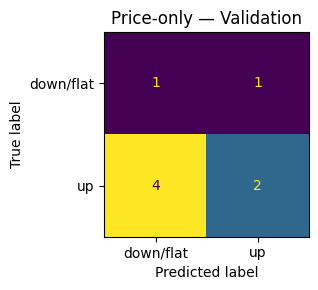


--- AII-augmented | Validation ---
Accuracy: 0.2500   ROC-AUC: 0.4167
              precision    recall  f1-score   support

   down/flat       0.17      0.50      0.25         2
          up       0.50      0.17      0.25         6

    accuracy                           0.25         8
   macro avg       0.33      0.33      0.25         8
weighted avg       0.42      0.25      0.25         8



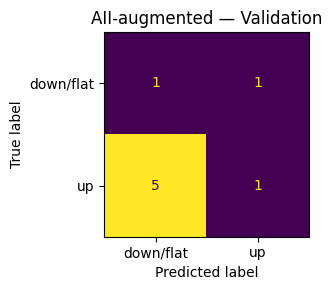


--- Price-only | Test ---
Accuracy: 0.5000   ROC-AUC: 0.5635
              precision    recall  f1-score   support

   down/flat       0.44      0.57      0.50         7
          up       0.57      0.44      0.50         9

    accuracy                           0.50        16
   macro avg       0.51      0.51      0.50        16
weighted avg       0.52      0.50      0.50        16



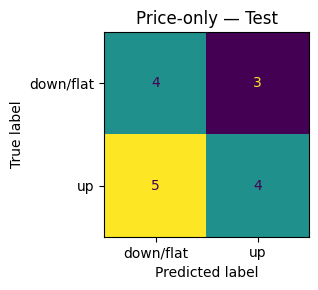


--- AII-augmented | Test ---
Accuracy: 0.4375   ROC-AUC: 0.5714
              precision    recall  f1-score   support

   down/flat       0.40      0.57      0.47         7
          up       0.50      0.33      0.40         9

    accuracy                           0.44        16
   macro avg       0.45      0.45      0.44        16
weighted avg       0.46      0.44      0.43        16



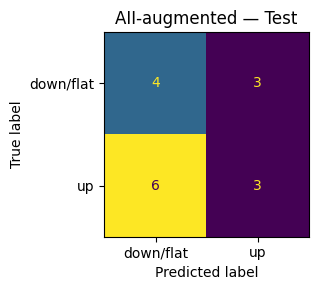

In [14]:
# Fit final models on full training set
clf_price_final = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100, max_depth=3, learning_rate=0.1,
    random_state=42, eval_metric='logloss',
)
clf_price_final.fit(X_price_train, y_cls_train)
clf_price_final.get_booster().feature_names = PRICE_FEATURES

clf_aii_final = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100, max_depth=3, learning_rate=0.1,
    random_state=42, eval_metric='logloss',
)
clf_aii_final.fit(X_aii_train, y_cls_train)
clf_aii_final.get_booster().feature_names = AII_FEATURES


def holdout_report(model, X, y, name, split_label):
    preds   = model.predict(X)
    proba   = model.predict_proba(X)[:, 1]
    acc     = accuracy_score(y, preds)
    auc     = roc_auc_score(y, proba) if len(np.unique(y)) > 1 else float('nan')
    print(f"\n--- {name} | {split_label} ---")
    print(f"Accuracy: {acc:.4f}   ROC-AUC: {auc:.4f}")
    print(classification_report(y, preds, target_names=['down/flat', 'up']))
    cm = confusion_matrix(y, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['down/flat', 'up'])
    fig, ax = plt.subplots(figsize=(4, 3))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{name} — {split_label}")
    plt.tight_layout()
    plt.show()


for split_label, X_p, X_a, y_s in [
    ('Validation', X_price_val, X_aii_val, y_cls_val),
    ('Test',       X_price_test, X_aii_test, y_cls_test),
]:
    holdout_report(clf_price_final, X_p, y_s, 'Price-only', split_label)
    holdout_report(clf_aii_final,   X_a, y_s, 'AII-augmented', split_label)

### Feature Importance

Which AII subcomponents contribute most to predictions?

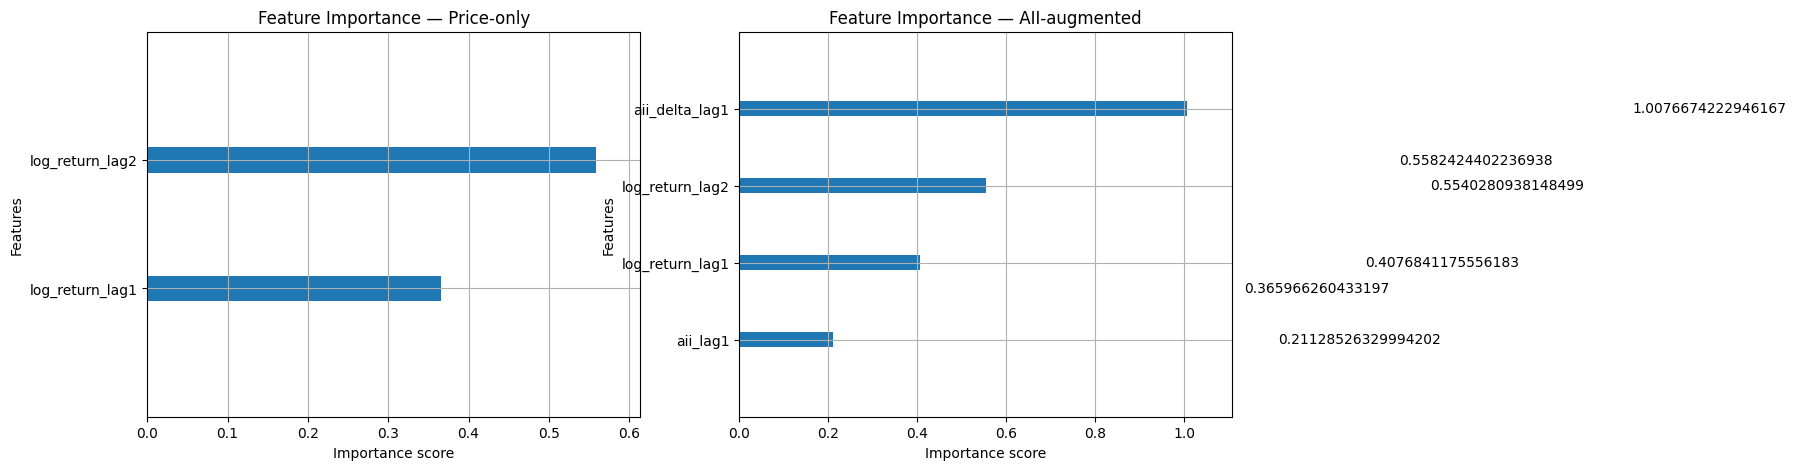

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_importance(
    clf_price_final,
    ax=axes[0],
    importance_type='gain',
    title='Feature Importance — Price-only',
)

plot_importance(
    clf_aii_final,
    ax=axes[1],
    importance_type='gain',
    title='Feature Importance — AII-augmented',
)

plt.tight_layout()
plt.show()

### Save Modeling Dataset

All features and targets saved for downstream use.

In [16]:
OUTPUT_PATH = '../data/processed/wday_modeling_dataset.csv'

# Add split assignment column for convenience
split_col = np.where(mask_train, 'train', np.where(mask_val, 'val', np.where(mask_test, 'test', 'unassigned')))
modeling = modeling.with_columns(pl.Series('split', split_col))

modeling.write_csv(OUTPUT_PATH)
print(f"Saved modeling dataset → {OUTPUT_PATH}")
print(f"Shape: {modeling.shape}")
print()
print("Split counts:")
print(modeling['split'].value_counts().sort('split'))

print()
print("=" * 60)
print("Leakage Prevention Summary")
print("=" * 60)
rows = [
    ('aii_lag1 (AII from Q-1)',      '+1 quarter', 'Yes — AII(Q) finalized end of Q'),
    ('aii_delta_lag1',                '+1 quarter', 'Yes'),
    ('bucket_*_lag1',                 '+1 quarter', 'Yes'),
    ('log_return_lag1',               '+1 quarter', 'Yes'),
    ('log_return_lag2',               '+2 quarters','Yes'),
    ('Target (Return Q)',             '—',          'Predicted, never an input'),
]
print(f"{'Feature':<35} {'Lag':<14} {'Safe?'}")
print('-' * 60)
for feature, lag, safe in rows:
    print(f"{feature:<35} {lag:<14} {safe}")

print()
print("Filing delay note: 10-Q filings are due ~40 days after quarter-end.")
print("AII(Q) isn't fully observable until ~40 days into Q+1.")
print("The 1-quarter lag is conservative enough for quarterly prediction.")
print("This is a known limitation that should be acknowledged in reporting.")

Saved modeling dataset → ../data/processed/wday_modeling_dataset.csv
Shape: (44, 22)

Split counts:
shape: (3, 2)
┌───────┬───────┐
│ split ┆ count │
│ ---   ┆ ---   │
│ str   ┆ u32   │
╞═══════╪═══════╡
│ test  ┆ 16    │
│ train ┆ 20    │
│ val   ┆ 8     │
└───────┴───────┘

Leakage Prevention Summary
Feature                             Lag            Safe?
------------------------------------------------------------
aii_lag1 (AII from Q-1)             +1 quarter     Yes — AII(Q) finalized end of Q
aii_delta_lag1                      +1 quarter     Yes
bucket_*_lag1                       +1 quarter     Yes
log_return_lag1                     +1 quarter     Yes
log_return_lag2                     +2 quarters    Yes
Target (Return Q)                   —              Predicted, never an input

Filing delay note: 10-Q filings are due ~40 days after quarter-end.
AII(Q) isn't fully observable until ~40 days into Q+1.
The 1-quarter lag is conservative enough for quarterly prediction.
This is